# 01 — Exploratory Data Analysis: SPY Volatility

This notebook explores the SPY price series, log returns, and the three realized-volatility
targets used downstream. It also annotates major market events and inspects volatility
clustering and lag-target correlations.

Run `python -m data.fetch` and `python run_experiments.py` from the project root before
this notebook so `data/spy.csv` and `data/features.csv` exist.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd().parent if (Path.cwd() / 'notebooks').exists() is False else Path.cwd()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from features.engineer import build_features  # noqa: E402

spy = pd.read_csv(PROJECT_DIR / 'data' / 'spy.csv', parse_dates=['Date'])
features_df, spec = build_features(spy)
print(features_df.shape, list(spec.feature_cols), list(spec.target_cols))
features_df.head()

(3480, 15) ['vol_1d', 'vol_5d', 'vol_21d', 'ret_sq_lag1', 'ret_abs_lag1', 'dow', 'month'] ['target_1d', 'target_5d', 'target_21d']


,Date,Close,log_return,vol_1d,vol_5d,vol_21d,ret_sq,ret_abs,ret_sq_lag1,ret_abs_lag1,dow,month,target_1d,target_5d,target_21d
0,2010-02-03,109.830002,-0.004995,-2.534563,-1.589786,-1.803090,0.000025,0.004995,0.000145,0.012031,2,2,-0.697754,-1.351270,-1.815963
1,2010-02-04,106.440002,-0.031352,-0.697754,-1.202886,-1.641981,0.000983,0.031352,0.000025,0.004995,3,2,-3.418022,-2.027474,-2.211795
2,2010-02-05,106.660004,0.002065,-3.418022,-1.219196,-1.639942,0.000004,0.002065,0.000983,0.031352,4,2,-2.162670,-2.004380,-2.211157
3,2010-02-08,105.889999,-0.007245,-2.162670,-1.364918,-1.646912,0.000052,0.007245,0.000004,0.002065,0,2,-1.618753,-2.060862,-2.277152
4,2010-02-09,107.220001,0.012482,-1.618753,-1.357087,-1.613015,0.000156,0.012482,0.000052,0.007245,1,2,-3.469840,-2.133268,-2.325245


In [2]:
spy.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,84.796387,113.330002,113.389999,111.510002,112.370003,118944600
1,2010-01-05,85.020836,113.629997,113.680000,112.849998,113.260002,111579900
2,2010-01-06,85.080711,113.709999,113.989998,113.430000,113.519997,116074400
3,2010-01-07,85.439842,114.190002,114.330002,113.180000,113.500000,131091100
4,2010-01-08,85.724167,114.570000,114.620003,113.660004,113.889999,126402800


## SPY price and log returns

Prices show the long-term uptrend with two notable regime changes annotated below.

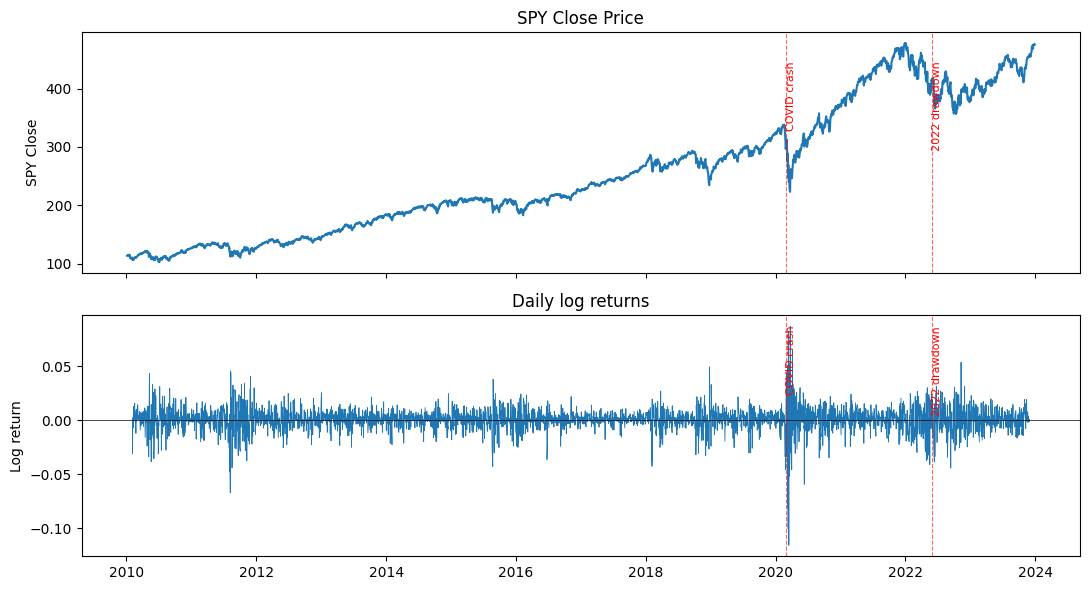

In [3]:
events = {
    'COVID crash': '2020-03-01',
    '2022 drawdown': '2022-06-01',
}

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(spy['Date'], spy['Close'])
axes[0].set_ylabel('SPY Close')
axes[0].set_title('SPY Close Price')

axes[1].plot(features_df['Date'], features_df['log_return'], lw=0.6)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_ylabel('Log return')
axes[1].set_title('Daily log returns')

for ax in axes:
    for label, date in events.items():
        ax.axvline(pd.Timestamp(date), color='red', ls='--', lw=0.8, alpha=0.6)
        ax.text(pd.Timestamp(date), ax.get_ylim()[1] * 0.9, label, color='red', fontsize=8, rotation=90, va='top')

plt.tight_layout()
plt.show()

## Realized volatility series across horizons

All three target series live in annualized log-vol space. They mostly track each other
but shorter horizons are noisier and longer horizons are smoother.

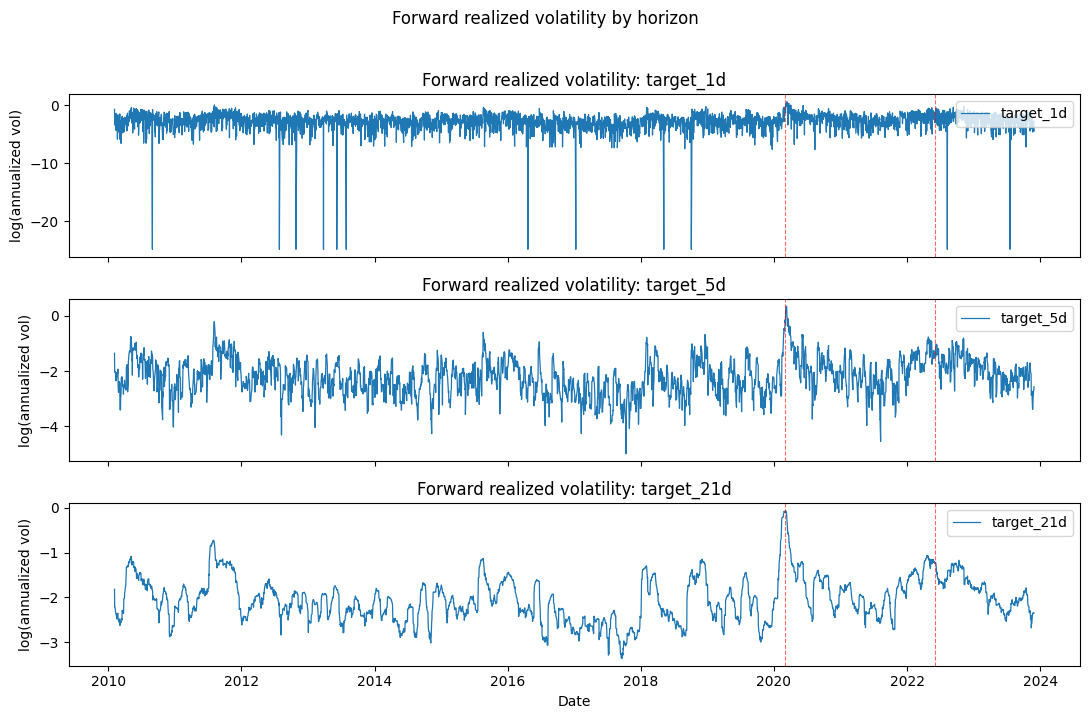

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

for ax, h in zip(axes, (1, 5, 21)):
    ax.plot(features_df['Date'], features_df[f'target_{h}d'], lw=0.9, label=f'target_{h}d')
    ax.set_title(f'Forward realized volatility: target_{h}d')
    ax.set_ylabel('log(annualized vol)')
    ax.legend(loc='upper right')
    for _, date in events.items():
        ax.axvline(pd.Timestamp(date), color='red', ls='--', lw=0.8, alpha=0.6)

axes[-1].set_xlabel('Date')
fig.suptitle('Forward realized volatility by horizon', y=1.02)
plt.tight_layout()
plt.show()

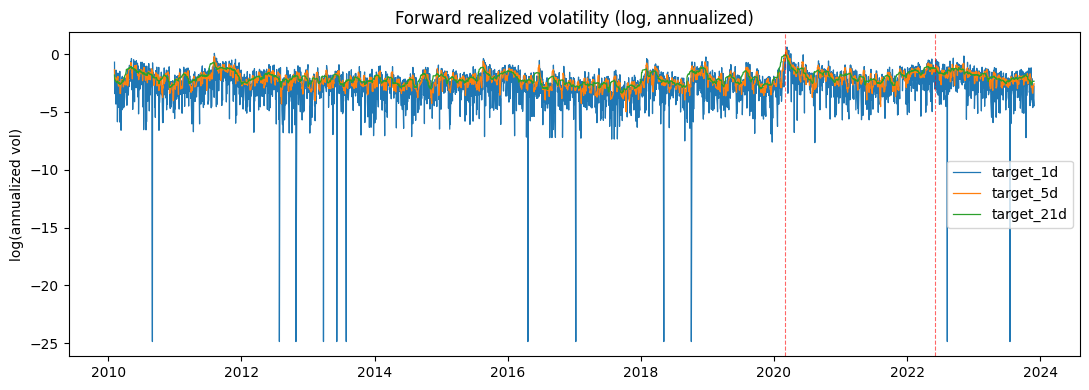

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
for h in (1, 5, 21):
    ax.plot(features_df['Date'], features_df[f'target_{h}d'], label=f'target_{h}d', lw=0.9)
ax.set_ylabel('log(annualized vol)')
ax.set_title('Forward realized volatility (log, annualized)')
ax.legend()
for label, date in events.items():
    ax.axvline(pd.Timestamp(date), color='red', ls='--', lw=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## Volatility clustering

We compare the autocorrelation of returns vs. squared returns. Returns are roughly
uncorrelated, while squared returns show a long-lived positive autocorrelation — the
classical sign of volatility clustering that motivates GARCH/HAR/LSTM-style models.

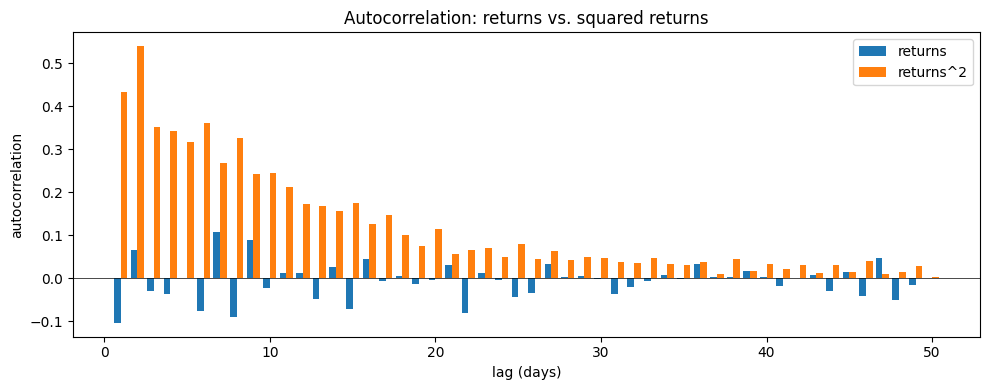

In [8]:
from pandas.plotting import autocorrelation_plot

max_lag = 50
ret = features_df['log_return'].dropna()
ret_sq = (ret ** 2)

def acf(x, lag):
    return [x.autocorr(l) for l in range(1, lag + 1)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(1, max_lag + 1) - 0.2, acf(ret, max_lag), width=0.4, label='returns')
ax.bar(np.arange(1, max_lag + 1) + 0.2, acf(ret_sq, max_lag), width=0.4, label='returns^2')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('lag (days)')
ax.set_ylabel('autocorrelation')
ax.set_title('Autocorrelation: returns vs. squared returns')
ax.legend()
plt.tight_layout()
plt.show()

## Correlation of lagged vol with forward targets

Sanity check: if HAR-style features are useful, lagged realized vol should be strongly
correlated with forward realized vol at the matching horizon.

In [9]:
lag_cols = ['vol_1d', 'vol_5d', 'vol_21d']
target_cols = ['target_1d', 'target_5d', 'target_21d']
corr = features_df[lag_cols + target_cols].corr().loc[lag_cols, target_cols]
corr.style.format('{:.3f}').background_gradient(axis=None)

,target_1d,target_5d,target_21d
vol_1d,0.052,0.199,0.203
vol_5d,0.233,0.530,0.509
vol_21d,0.236,0.550,0.540
